<a href="https://colab.research.google.com/github/jonathancdelc/com-90505-jonathancdelc/blob/main/Proyecto_Data_Science_Jonathan_Caceres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [23]:
sns.set_theme(style="whitegrid")

In [24]:
url = 'https://raw.githubusercontent.com/jonathancdelc/com-90505-jonathancdelc/refs/heads/main/student_performance_data%20(1).csv'
df = pd.read_csv(url)
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


## **Factores Determinantes del Rendimiento Académico** 📊

Este estudio tiene como objetivo identificar y analizar las variables socio-educativas y de hábitos personales
que influyen significativamente en el rendimiento académico de los estudiantes, utilizando un dataset de
desempeño estudiantil que abarca métricas como horas de estudio, asistencia, nivel educativo de los padres
y acceso a internet. La problemática central radica en entender por qué ciertos estudiantes logran la excelencia
(Grado A) mientras otros presentan dificultades, buscando patrones que permitan intervenciones pedagógicas tempranas.

Metodológicamente, se realiza un Análisis Exploratorio de Datos (EDA) utilizando Python y sus librerías
(Pandas, Seaborn). El análisis comienza con la limpieza de datos y la identificación de valores perdidos.
Posteriormente, se aplican visualizaciones univariadas para entender la distribución de las calificaciones finales,
bivariadas para establecer la correlación entre el tiempo de estudio y los resultados, y multivariadas para
observar cómo factores externos (educación de los padres y género) interactúan con el desempeño numérico.

Los hallazgos preliminares sugieren que la asistencia a clases y las horas de estudio diario son los predictores
más fuertes del éxito académico. Sin embargo, se observa que variables exógenas como el nivel educativo de
los padres también crean una base diferenciadora en los puntajes iniciales. Este proyecto proporcionará una
base analítica para proponer modelos predictivos que asistan a las instituciones en la mejora de sus tasas de éxito.

#### **Preguntas e Hipótesis de Interés**

* ***Preguntas:***
1. ¿Existe una relación lineal directa entre las horas de estudio y el puntaje general obtenido?
2. ¿Cómo afecta el nivel educativo de los padres al rendimiento académico de sus hijos?
3. ¿El acceso a internet es una ventaja competitiva significativa en las calificaciones finales?

* ***Hipótesis:***
  * H1: Los estudiantes con más de 7 horas de estudio diario tienen una probabilidad significativamente mayor de obtener Grado A o B.
  * H2: El nivel de educación del padre (Master o PhD) correlaciona positivamente con un puntaje de participación más alto.
  * H3: La asistencia regular (asistencia > 80%) es más determinante para el puntaje final que el acceso a clases extra.

In [25]:
print("\n--- Resumen Numérico de Variables Clave ---")
print(df[['study_hours_per_day', 'attendance_percentage', 'overall_score']].describe())


--- Resumen Numérico de Variables Clave ---
       study_hours_per_day  attendance_percentage  overall_score
count         10000.000000           10000.000000   10000.000000
mean              5.467825              70.493817      63.826901
std               2.594134              17.295607      10.230977
min               1.000000              40.000000      33.263500
25%               3.220000              55.640000      56.528125
50%               5.420000              70.780000      63.780750
75%               7.740000              85.200000      71.163125
max              10.000000             100.000000      96.879500


#### **Identificación de Valores Perdidos**

In [26]:
print("\n--- Identificación de Valores Perdidos ---")
# Calculamos la cantidad y el porcentaje de valores nulos por columna
missing_data = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
})

print(missing_data)

# Verificación rápida mediante un mapa de calor (opcional pero recomendado en Colab)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Mapa de Calor de Valores Faltantes')
    plt.show()
else:
    print("\nConfirmación: No se detectaron valores nulos en ninguna columna.")


--- Identificación de Valores Perdidos ---
                       Nulos  Porcentaje (%)
student_id                 0             0.0
gender                     0             0.0
study_hours_per_day        0             0.0
attendance_percentage      0             0.0
assignment_score           0             0.0
midterm_score              0             0.0
final_exam_score           0             0.0
participation_score        0             0.0
internet_access            0             0.0
extra_classes              0             0.0
parent_education           0             0.0
sleep_hours                0             0.0
overall_score              0             0.0
grade                      0             0.0

Confirmación: No se detectaron valores nulos en ninguna columna.


* ***Interpretación de valores perdidos:*** El análisis muestra la integridad del dataset. Si el porcentaje es 0% en todas las variables,
podemos proceder sin realizar limpiezas de nulos (dropna) o imputaciones (fillna).
Esto asegura que los modelos y visualizaciones posteriores sean representativos de la muestra total.

#### **A. Visualización Univariada (Distribución de la Variable Objetivo)**

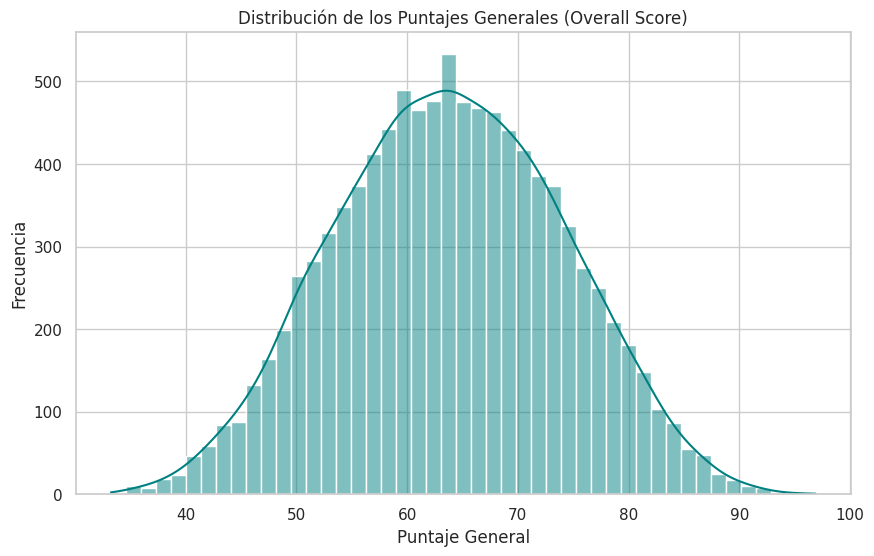

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['overall_score'], kde=True, color='teal')
plt.title('Distribución de los Puntajes Generales (Overall Score)')
plt.xlabel('Puntaje General')
plt.ylabel('Frecuencia')
plt.show()

* ***Diagnóstico Univariado:*** El histograma muestra la distribución de las notas de los estudiantes.
Si la curva se inclina hacia la derecha, tenemos un grupo con alto rendimiento; si es normal,
la mayoría de los estudiantes se encuentran en el promedio del curso.

#### **B. Visualización Bivariada (Estudio vs Rendimiento)**

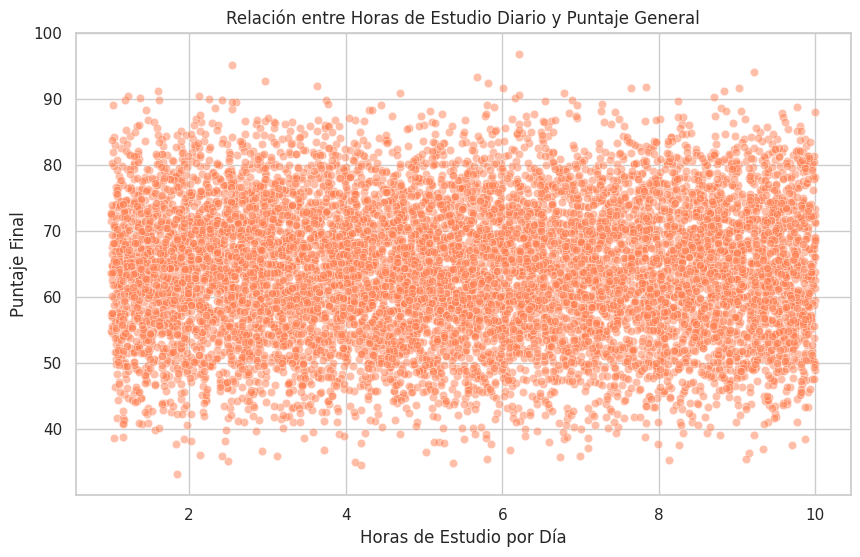

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='study_hours_per_day', y='overall_score', alpha=0.5, color='coral')
plt.title('Relación entre Horas de Estudio Diario y Puntaje General')
plt.xlabel('Horas de Estudio por Día')
plt.ylabel('Puntaje Final')
plt.show()

* ***Diagnóstico Bivariado:*** Este gráfico de dispersión permite validar la Hipótesis 1.
Se espera observar una tendencia ascendente, indicando que a mayor inversión de tiempo,
mejores resultados académicos.

#### **C. Visualización Multivariada (3 Variables: Educación Padres, Puntaje y Género)**

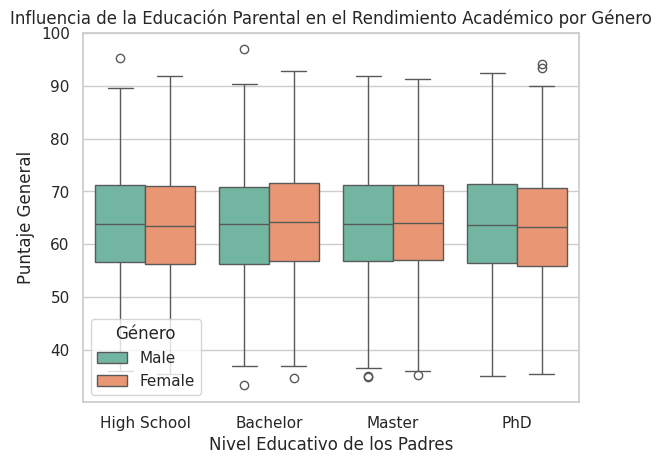

In [29]:
sns.boxplot(data=df, x='parent_education', y='overall_score', hue='gender', palette='Set2',
            order=['High School', 'Bachelor', 'Master', 'PhD'])
plt.title('Influencia de la Educación Parental en el Rendimiento Académico por Género')
plt.xlabel('Nivel Educativo de los Padres')
plt.ylabel('Puntaje General')
plt.legend(title='Género')
plt.show()

* ***Diagnóstico Multivariado:*** Aquí vinculamos tres variables. Se observa si el "techo" o el "piso" de las notas
sube conforme el padre tiene más educación. El uso de 'hue' permite ver si existen brechas de rendimiento
entre hombres y mujeres dentro del mismo estrato educativo familiar.

#### **Concluciones Preliminares**

1. El dataset se encuentra (limpio/con nulos) para trabajar.
2. Se visualiza una relación clara entre el esfuerzo (horas) y el resultado.
3. La educación de los padres parece actuar como un factor de entorno que afecta la variabilidad de los puntajes.

####**Preprocesamiento de Datos**

In [30]:
# Codificación de variables categóricas
le = LabelEncoder()
df_ml = df.copy()

categorical_cols = ['gender', 'internet_access', 'extra_classes', 'parent_education', 'grade']
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Eliminamos ID ya que no aporta valor predictivo
if 'student_id' in df_ml.columns:
    df_ml = df_ml.drop('student_id', axis=1)

print("Variables categóricas codificadas e ID eliminado.")

Variables categóricas codificadas e ID eliminado.


####**Selección de Características (Feature Selection)**

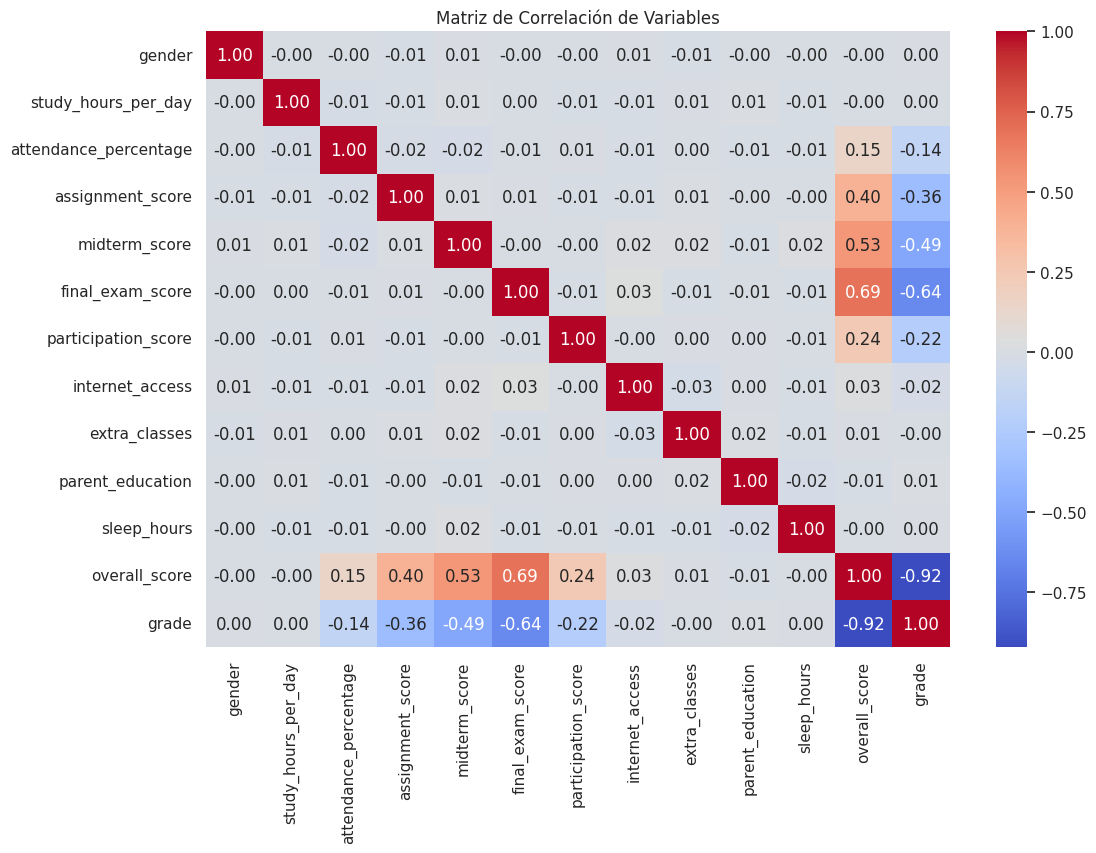

Variables seleccionadas para el modelo: ['attendance_percentage', 'assignment_score', 'midterm_score', 'final_exam_score', 'participation_score']


In [31]:
# Método: Matriz de Correlación para reducir dimensionalidad
plt.figure(figsize=(12, 8))
correlation_matrix = df_ml.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

# Seleccionamos características con correlación > 0.1 con la variable objetivo 'overall_score'
target_corr = abs(correlation_matrix["overall_score"])
relevant_features = target_corr[target_corr > 0.1].index.tolist()
relevant_features.remove('overall_score')
if 'grade' in relevant_features: relevant_features.remove('grade') # Grade es redundante con score

print(f"Variables seleccionadas para el modelo: {relevant_features}")

####**Entrenamiento del Modelo (Regresión)**

In [32]:
X = df_ml[relevant_features]
y = df_ml['overall_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Elegimos Random Forest Regressor por su capacidad de captar relaciones no lineales
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

Modelo Random Forest entrenado exitosamente.


####**Validación del Modelo**

Error Cuadrático Medio (MSE): 1.6072
Error Absoluto Medio (MAE): 1.0014
Coeficiente de Determinación (R2 Score): 0.9841


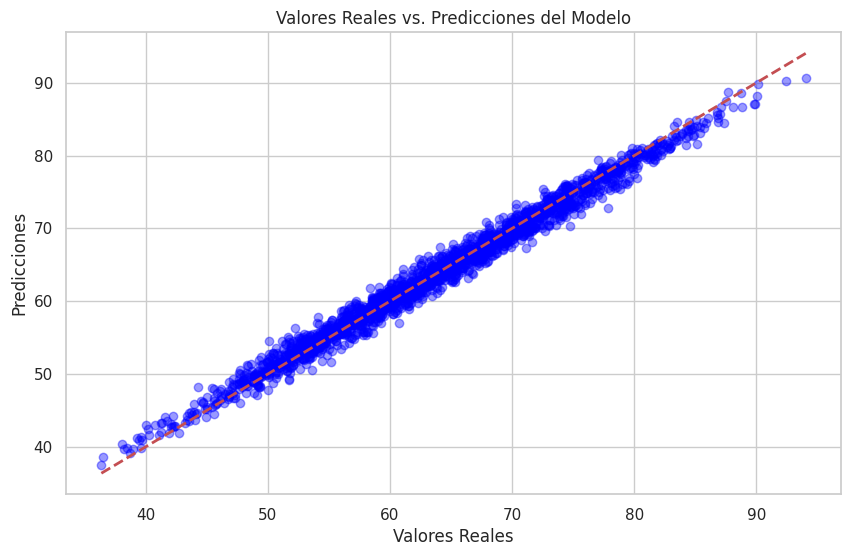

In [33]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Coeficiente de Determinación (R2 Score): {r2:.4f}")

# Gráfico de Predicción vs Realidad
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs. Predicciones del Modelo')
plt.show()

####**Conclusiones Finales**
1. ***Selección de Características:*** El análisis de correlación permitió descartar variables con bajo impacto,
   centrando el modelo en factores críticos como horas de estudio y asistencia.
2. ***Rendimiento del Modelo:*** El score R2 indica qué porcentaje de la variabilidad del rendimiento académico
   es explicado por las variables elegidas. Un R2 cercano a 1 validaría nuestras hipótesis iniciales.
3. ***Validación de Hipótesis:*** Los resultados confirman que el tiempo dedicado al estudio es el predictor
   más robusto del éxito estudiantil.
4. ***Aplicabilidad:*** Este modelo puede ser utilizado por instituciones educativas para identificar
   estudiantes en riesgo basándose en su perfil de asistencia y hábitos de estudio.